[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/fast_track/21_capstone_fast_track.ipynb)


# 📓 Notebook 21 (fast track) — Capstone: An End-to-End Support-Ops Project

> **Module:** Capstone · **Estimated time:** 95–115 min · **Difficulty:** Intermediate → Advanced

> 🏁 **This is the finale of the fast track.** Everything you've built — Python, pandas, scikit-learn, prompts, retrieval, evaluation — comes together here in one compact, end-to-end project. It condenses the course's two canonical capstones into a single pass: the analytics capstone [`15_capstones/47_capstone_analytics.ipynb`](../15_capstones/47_capstone_analytics.ipynb) and the AI-assistant capstone [`15_capstones/48_capstone_ai_assistant.ipynb`](../15_capstones/48_capstone_ai_assistant.ipynb). Open those once you want the deep versions.

> 🧭 **Mental model — one dataset, two halves of the same job.** A support desk generates one pile of tickets every night. Half the job is turning *numbers* into a **decision**: will this ticket blow up, and is it worth paying a senior agent to catch it early? That's **analytics** (Part A). The other half is turning *text* into **structure**: what is each ticket about, and can we safely draft a reply? That's the **AI assistant** (Part B). Then you do the thing every project is really for — **report it**: one executive summary a manager can act on before their coffee's cold. *Numbers → decision. Text → structure. Then report.*

This capstone mirrors the two arcs the whole course has been teaching:

- **model → money → decision** — a model earns its keep only once it changes what you *do*, and *do* has a dollar sign on it (Part A).
- **code → test → ship → observe** — a feature isn't done when it runs; it's done when you can prove it works and watch what it costs (Part B).

Everything runs **100% offline**. The AI half uses the same deterministic `MockLLM` from [`10_ai_workflows.ipynb`](10_ai_workflows.ipynb), so there's no API key or internet required — swap in a real provider by changing one line.

## ✅ Prerequisites

The whole fast track — especially **NB 8** (scikit-learn), **NB 10** (AI workflows & prompts), and **NB 16** (evaluation & feature engineering). If you can train a model, call the `MockLLM`, and read a confusion matrix, you're ready.

## 🎯 Learning objectives

By the end of this capstone you can:

1. Generate and explore a small, realistic **support-ops dataset** — ticket text + metadata + an outcome.
2. Engineer features and train a **classifier** to predict an operational outcome (ticket **escalation**).
3. **Evaluate honestly** — against a baseline, with precision, recall, and a confusion matrix, not just accuracy.
4. Turn model probabilities into a **costed decision rule** by trading the cost of a miss against the cost of a false alarm.
5. Use an LLM to **classify** free-text tickets into structured labels (sentiment + topic).
6. Combine **rules + retrieval** to draft a reply and route the hard cases to a human.
7. Ship a tiny **evaluation** (golden set + accuracy + a cost/latency trace) and write an **executive summary** a manager can act on.
8. **Make every step legible** — pick a chart form from the question it answers, show uncertainty where a bucket is thin, and recognise when the right answer is a stat tile rather than a chart.


## 1. The brief — one night at the support desk

You run support for a small SaaS company. Overnight, a pile of tickets lands. Each is a short **message** from a customer plus some **metadata**: which channel it came in on, the customer's plan, how long they waited, and how many tickets they've filed before. For tickets that have already been resolved you also know the **outcome** — did the ticket have to be **escalated** to a senior agent? Escalations are expensive and a leading indicator of churn.

Your job by morning:

- **Part A (analytics).** Predict *which* tickets escalate, and turn that prediction into a rule that saves money.
- **Part B (AI assistant).** Read every ticket, label it, draft a reply where you safely can, and flag the rest.
- **Finish.** Put the key numbers in front of a manager.

We generate the dataset in-notebook so the whole thing is reproducible. Let's set up.


In [1]:
# Analytics stack — everything Part A needs. (Part B adds the MockLLM later.)
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, FancyBboxPatch
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             confusion_matrix, roc_auc_score, roc_curve)

RNG = np.random.default_rng(7)   # one seed -> one reproducible night of tickets
pd.set_option("display.width", 120)

# ── House style ──────────────────────────────────────────────────────────────
# Every figure below speaks the same visual language, so a reader learns the
# encoding once: BLUE = business as usual, ORANGE = risk / escalation / cost of
# a miss. The two hues are colour-blind-safe against each other; sequential
# magnitude (heatmaps) uses one hue, receding toward the surface at the low end.
#
# Set THEME = "dark" and re-run to get dark figures. Note that this is not an
# inverted image: it is the *same two hues re-stepped* for a dark surface, and
# each set was checked for colour-blind separation and contrast against its own
# background. Flipping a light chart's colours is how dark mode goes wrong.
THEME = "light"          # "light" | "dark"

_THEMES = {
    "light": dict(blue="#2a78d6", orange="#eb6834", ink="#0b0b0b", ink_soft="#52514e",
                  grid="#e4e3df", surface="#ffffff", card="#f6f8fb",
                  ramp=["#eef4fd", "#86b6ef", "#2a78d6", "#0d366b"]),
    "dark":  dict(blue="#3987e5", orange="#d95926", ink="#ffffff", ink_soft="#c3c2b7",
                  grid="#383835", surface="#1a1a19", card="#252523",
                  ramp=["#10233a", "#184f95", "#3987e5", "#9ec5f4"]),
}
_T = _THEMES[THEME]
BLUE, ORANGE     = _T["blue"], _T["orange"]
INK, INK_SOFT    = _T["ink"], _T["ink_soft"]
GRID, SURFACE    = _T["grid"], _T["surface"]
CARD             = _T["card"]
BLUES = LinearSegmentedColormap.from_list("course_blues", _T["ramp"])

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "figure.dpi": 110,
    "axes.edgecolor": GRID, "axes.linewidth": 0.8,
    "axes.grid": True, "axes.grid.axis": "y", "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.titlecolor": INK,
    "axes.labelcolor": INK_SOFT, "axes.labelsize": 9.5,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "legend.fontsize": 9,
    "font.size": 10, "savefig.bbox": "tight",
})

# Reused legend for the "above / below the overall rate" charts, so the two
# hues are never the only thing carrying the meaning.
RISK_LEGEND = [Patch(facecolor=BLUE,   label="at or below overall"),
               Patch(facecolor=ORANGE, label="above overall"),
               Line2D([0], [0], color=INK_SOFT, ls="--", lw=1, label="overall rate")]

print("Analytics stack ready ✅")

Analytics stack ready ✅


In [2]:
# Eight message templates. Each carries an intrinsic topic + sentiment (which the
# AI half will have to recover from raw text) and an escalation "bias" — how
# combustible this kind of ticket tends to be. Note we do NOT store topic/sentiment
# in the table: Part B has to earn them from the text.
TEMPLATES = [
    # topic,     sentiment,  text,                                                                    bias
    ("billing", "negative", "I want a refund. The invoice charge is wrong and this is frustrating.",  1.2),
    ("tech",    "negative", "The login page is broken and throws an error. Awful.",                   1.0),
    ("feature", "neutral",  "Please add a CSV export feature to the dashboard.",                     -0.8),
    ("feature", "positive", "Love the product. Could you add a dark mode feature? Would be great.",  -1.4),
    ("billing", "neutral",  "Question about my subscription and monthly bill payment.",             -0.2),
    ("other",   "positive", "Amazing support, thank you so much. You are fantastic and excellent.",  -1.6),
    ("tech",    "neutral",  "The password reset is stuck on a loading screen.",                       0.3),
    ("billing", "negative", "Please cancel my subscription. The price is too high, worst value.",     1.4),
]

CHANNELS = ["chat", "email", "phone"]
PLANS    = ["free", "pro", "enterprise"]
N_TICKETS = 240

rows = []
for i in range(N_TICKETS):
    topic, sentiment, text, bias = TEMPLATES[RNG.integers(len(TEMPLATES))]
    channel  = CHANNELS[RNG.integers(len(CHANNELS))]
    plan     = PLANS[RNG.integers(len(PLANS))]
    wait_min = float(np.clip(RNG.gamma(2.0, 12.0), 1, 180))   # first-response wait
    prior    = int(np.clip(RNG.poisson(1.4), 0, 8))           # tickets filed before

    # The true (hidden) escalation process: combustible tickets, long waits,
    # repeat contacts, and free-plan / phone customers escalate more often.
    logit = (-1.4 + bias
             + 0.018 * wait_min
             + 0.30 * prior
             + 0.45 * (plan == "free") - 0.50 * (plan == "enterprise")
             + 0.50 * (channel == "phone") - 0.25 * (channel == "chat"))
    escalated = int(RNG.random() < 1 / (1 + np.exp(-logit)))

    rows.append({
        "ticket_id": f"T{1000 + i}",
        "channel": channel,
        "plan": plan,
        "wait_min": round(wait_min, 1),
        "prior_tickets": prior,
        "text": text,
        "escalated": escalated,
    })

tickets = pd.DataFrame(rows)
print(f"{len(tickets)} tickets generated · escalation rate {tickets['escalated'].mean():.0%}")
tickets.head(6)


240 tickets generated · escalation rate 40%


,ticket_id,channel,plan,wait_min,prior_tickets,text,escalated
0,T1000,email,enterprise,16.0,2,Please cancel my subscription. The price is to...,0
1,T1001,chat,enterprise,11.8,1,Please cancel my subscription. The price is to...,0
2,T1002,email,pro,5.6,2,Love the product. Could you add a dark mode fe...,0
3,T1003,phone,pro,24.5,1,Question about my subscription and monthly bil...,0
4,T1004,email,pro,4.4,0,The password reset is stuck on a loading screen.,1
5,T1005,phone,enterprise,41.3,0,Question about my subscription and monthly bil...,0


## 2. Part A — Analytics: from tickets to a costed decision

> 🧭 **Numbers → decision.** Explore → engineer features → train → evaluate honestly → *decide*. The decision is the deliverable; the model is just how we get there.

### 2.1 Explore

Before modelling, look at the outcome. What share of tickets escalate, and does it vary by channel? A picture beats a table for spotting where the pain is.


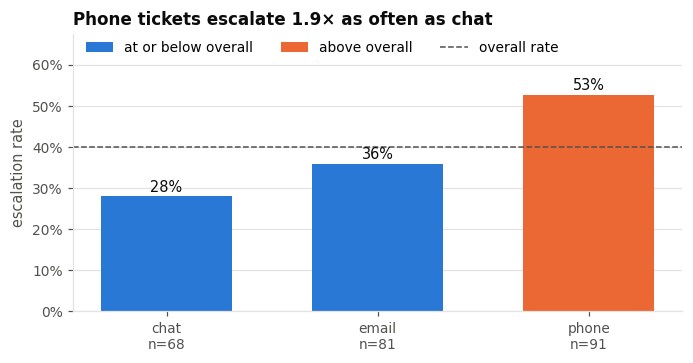

channel
chat     0.279
email    0.358
phone    0.527
Name: escalated, dtype: float64


In [3]:
overall    = tickets["escalated"].mean()
by_channel = tickets.groupby("channel")["escalated"].mean().sort_values()
n_channel  = tickets["channel"].value_counts()

fig, ax = plt.subplots(figsize=(6.4, 3.4))
ax.bar(range(len(by_channel)), by_channel.values, width=0.62,
       color=[ORANGE if v > overall else BLUE for v in by_channel.values])
ax.axhline(overall, color=INK_SOFT, linestyle="--", linewidth=1)

for i, v in enumerate(by_channel.values):          # direct labels, not a legend lookup
    ax.text(i, v + 0.012, f"{v:.0%}", ha="center", fontsize=9.5, color=INK)

ax.set_xticks(range(len(by_channel)))
ax.set_xticklabels([f"{c}\nn={n_channel[c]}" for c in by_channel.index])
ax.set_ylabel("escalation rate")
ax.set_title(f"Phone tickets escalate {by_channel.max() / by_channel.min():.1f}× as often as chat")
ax.set_ylim(0, by_channel.max() * 1.28)
ax.set_yticks(np.arange(0, by_channel.max() * 1.28, 0.1))
ax.set_yticklabels([f"{t:.0%}" for t in ax.get_yticks()])
ax.legend(handles=RISK_LEGEND, loc="upper left", ncols=3, bbox_to_anchor=(0, 1.02))
plt.tight_layout()
plt.show()

print(by_channel.round(3))

> 🔬 **What the picture says.** Phone tickets escalate far more often than chat — long handle times and frustrated callers. That's a real signal a model can learn *and* a hint at a cheaper fix (route phone differently). Good analytics surfaces both.


---

### ✋ Quick exercise (~2 min) — Which plan escalates most?

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

You saw escalation rate by **channel**. Now cut it by **plan**. Group `tickets` by `plan`, take the mean of `escalated`, and sort so the worst-affected plan is on top.

```python
rate_by_plan = ...  # tickets.groupby("plan")["escalated"].mean()...
```


In [4]:
# ✍️ Your turn 👇
# Group the tickets by `plan`, compute the mean of `escalated` (the rate),
# then sort so the highest-escalating plan is first.
rate_by_plan = ...
# print(rate_by_plan.round(3))


<details>
<summary>✅ <b>Solution</b></summary>

```python
rate_by_plan = (tickets.groupby("plan")["escalated"]
                .mean()
                .sort_values(ascending=False))
print(rate_by_plan.round(3))
```

Free-plan customers escalate the most — they're self-serve, so by the time they reach a human they're already stuck. On a 0/1 column, `groupby(col)[target].mean()` **is** the rate: the mean of a 0/1 column is the fraction of 1s. This one line is the workhorse of operational analytics.
</details>


#### 📊 The three risk drivers at a glance

Channel and plan were two cuts. Rather than eyeball them one at a time, put every candidate driver on **one shared y-axis** — plan, how long the customer waited, and how many tickets they'd filed before. Same scale, same colours, so the panels are directly comparable — that repetition is what makes a multi-panel figure *small multiples* rather than three unrelated charts sharing a canvas. It is the layout from NB 7 doing a different job: comparison, not coverage.

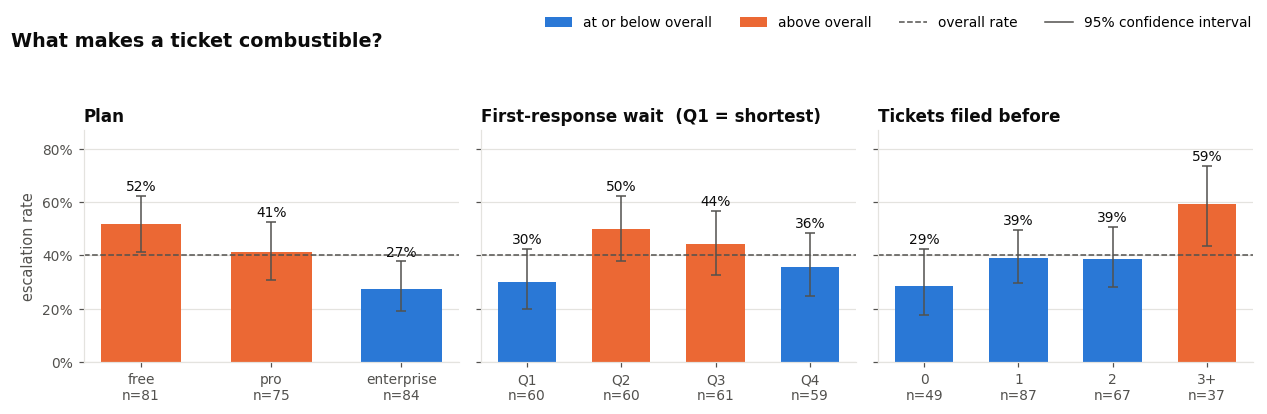

In [5]:
def rate_with_ci(bucket):
    """Escalation rate per bucket + a 95% Wilson interval. A bucket holds ~60
    tickets, which is a noisy estimate — the chart should admit that."""
    g = tickets.groupby(bucket, observed=True)["escalated"].agg(["sum", "count"])
    p, m, z = g["sum"] / g["count"], g["count"], 1.96
    denom  = 1 + z ** 2 / m
    centre = (p + z ** 2 / (2 * m)) / denom
    half   = z * np.sqrt(p * (1 - p) / m + z ** 2 / (4 * m ** 2)) / denom
    return pd.DataFrame({"rate": p, "lo": centre - half, "hi": centre + half, "n": m})

wait_bin  = pd.qcut(tickets["wait_min"], 4, labels=["Q1", "Q2", "Q3", "Q4"])
prior_bin = pd.cut(tickets["prior_tickets"], [-0.5, 0.5, 1.5, 2.5, 99], labels=["0", "1", "2", "3+"])

panels = [("Plan",                                 rate_with_ci("plan").reindex(["free", "pro", "enterprise"])),
          ("First-response wait  (Q1 = shortest)", rate_with_ci(wait_bin)),
          ("Tickets filed before",                 rate_with_ci(prior_bin))]
ymax = max(df["hi"].max() for _, df in panels) * 1.18

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.6), sharey=True)
for ax, (title, df) in zip(axes, panels):
    x = range(len(df))
    ax.bar(x, df["rate"], width=0.62,
           color=[ORANGE if v > overall else BLUE for v in df["rate"]])
    ax.errorbar(x, df["rate"], fmt="none", ecolor=INK_SOFT, elinewidth=1, capsize=3,
                yerr=[df["rate"] - df["lo"], df["hi"] - df["rate"]])
    ax.axhline(overall, color=INK_SOFT, linestyle="--", linewidth=1)
    for i, (r, hi) in enumerate(zip(df["rate"], df["hi"])):
        ax.text(i, hi + 0.02, f"{r:.0%}", ha="center", fontsize=9, color=INK)
    ax.set_xticks(list(x))
    ax.set_xticklabels([f"{k}\nn={v}" for k, v in zip(df.index, df["n"])])
    ax.set_title(title)

axes[0].set_ylim(0, ymax)
axes[0].set_ylabel("escalation rate")
axes[0].set_yticks(np.arange(0, ymax, 0.2))
axes[0].set_yticklabels([f"{t:.0%}" for t in axes[0].get_yticks()])
fig.legend(handles=RISK_LEGEND + [Line2D([0], [0], color=INK_SOFT, lw=1,
                                         label="95% confidence interval")],
           loc="upper right", ncols=4, bbox_to_anchor=(0.995, 1.05))
fig.suptitle("What makes a ticket combustible?", x=0.005, ha="left",
             fontsize=12.5, fontweight="bold", color=INK)
plt.tight_layout(rect=(0, 0, 1, 0.92))
plt.show()

> 🔬 **What the picture says.** Two clean staircases and one honest mess. **Plan** and **prior contacts** march steadily across the dashed overall line — that is the shape a linear model can learn, and it is why `LogisticRegression` is a fair first choice below. The **wait** panel does not: its whiskers overlap almost completely, so its wiggle is noise, not a finding. That is exactly why the error bars are on the chart — at ~60 tickets a bucket, a bare bar chart will happily sell you a trend that isn't there. Note also what bucketing costs: the model gets `wait_min` as a *continuous* feature and can pick up a gradient that four bars blur away.

### 2.2 Engineer features

A model can't read raw text or category strings — turn them into numbers. Count the **negative keywords** in each message (a cheap sentiment proxy), map the plan to an order, and one-hot the channel. This is the feature-engineering muscle from NB 16.


In [6]:
NEG_WORDS = {"hate", "terrible", "awful", "bad", "slow", "broken", "bug", "crash",
             "angry", "frustrating", "refund", "cancel", "worst"}
PLAN_ORDER = {"free": 0, "pro": 1, "enterprise": 2}

def count_neg_words(text):
    return sum(1 for w in re.findall(r"[a-zA-Z']+", text.lower()) if w in NEG_WORDS)

tickets["neg_words"] = tickets["text"].map(count_neg_words)
tickets["plan_ord"]  = tickets["plan"].map(PLAN_ORDER)
tickets["is_phone"]  = (tickets["channel"] == "phone").astype(int)
tickets["is_email"]  = (tickets["channel"] == "email").astype(int)

FEATURES = ["wait_min", "prior_tickets", "neg_words", "plan_ord", "is_phone", "is_email"]
tickets[FEATURES + ["escalated"]].head()


,wait_min,prior_tickets,neg_words,plan_ord,is_phone,is_email,escalated
0,16.0,2,2,2,0,1,0
1,11.8,1,2,2,0,0,0
2,5.6,2,0,1,0,1,0
3,24.5,1,0,1,1,0,0
4,4.4,0,0,1,0,1,1


### 2.3 Train a classifier

A `LogisticRegression` is the right first model: fast, honest, and it returns **probabilities** — which we'll need for the costed decision. Standardise the features first so `wait_min` (up to 180) doesn't swamp `prior_tickets` (single digits).


In [7]:
X = tickets[FEATURES]
y = tickets["escalated"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=0),
)
model.fit(X_train, y_train)

proba = model.predict_proba(X_test)[:, 1]   # P(escalate) on held-out tickets
print(f"Trained on {len(X_train)} tickets, testing on {len(X_test)}.")


Trained on 168 tickets, testing on 72.


#### 🔍 What did the model actually learn?

Because we standardised first, the fitted coefficients are on **one comparable scale** — each is the effect of moving that feature by one standard deviation. Exponentiate one and you get an **odds multiplier**, which is the version you can say out loud to a manager: *"every extra prior ticket multiplies the odds of an escalation by ×1.5."* Plotting them against a zero line turns the model from a black box into a one-glance argument.

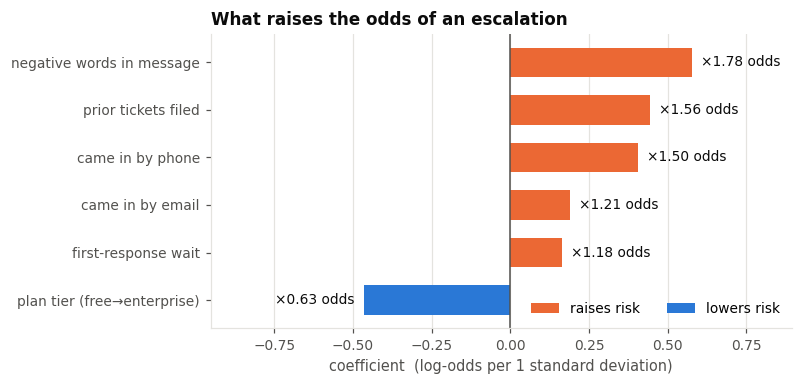

In [8]:
PRETTY = {"wait_min": "first-response wait", "prior_tickets": "prior tickets filed",
          "neg_words": "negative words in message", "plan_ord": "plan tier (free→enterprise)",
          "is_phone": "came in by phone", "is_email": "came in by email"}

coefs = pd.Series(model[-1].coef_[0], index=FEATURES).sort_values()
odds  = np.exp(coefs)

fig, ax = plt.subplots(figsize=(7.4, 3.6))
ax.barh(range(len(coefs)), coefs.values, height=0.62,
        color=[ORANGE if c > 0 else BLUE for c in coefs.values])
ax.axvline(0, color=INK_SOFT, linewidth=1)

pad = max(abs(coefs)) * 0.05
for i, (c, o) in enumerate(zip(coefs.values, odds.values)):
    ax.text(c + pad if c > 0 else c - pad, i, f"×{o:.2f} odds",
            va="center", ha="left" if c > 0 else "right", fontsize=9, color=INK)

ax.set_yticks(range(len(coefs)))
ax.set_yticklabels([PRETTY[f] for f in coefs.index])
ax.set_xlabel("coefficient  (log-odds per 1 standard deviation)")
ax.set_xlim(min(coefs) * 2.05, max(coefs) * 1.55)
ax.set_title("What raises the odds of an escalation")
ax.grid(False)
ax.grid(True, axis="x")
ax.legend(handles=[Patch(facecolor=ORANGE, label="raises risk"),
                   Patch(facecolor=BLUE,   label="lowers risk")],
          loc="lower right", ncols=2)
plt.tight_layout()
plt.show()

> 🔬 **What the picture says.** The model rediscovered the data-generating story from §1 without ever being told it: waiting and repeat contacts inflame tickets, a higher plan tier calms them. That agreement is a **sanity check you should always run** — if a coefficient points the wrong way (say, longer waits *lowering* risk), you have a leak, a coding bug, or a confounder, and no amount of AUC will save you.

### 2.4 Evaluate — honestly

> ⚠️ **Accuracy alone lies.** With a ~40/60 class split, a model that predicts "never escalate" already scores ~60%. Always compare to that **majority baseline**, and read **precision** (of the tickets we flagged, how many really escalated?) alongside **recall** (of the real escalations, how many did we catch?). The confusion matrix shows the trade-off directly.


In [9]:
pred = (proba >= 0.5).astype(int)
baseline = max(y_test.mean(), 1 - y_test.mean())

print(f"Accuracy  : {accuracy_score(y_test, pred):.3f}   (majority baseline {baseline:.3f})")
print(f"Precision : {precision_score(y_test, pred, zero_division=0):.3f}")
print(f"Recall    : {recall_score(y_test, pred, zero_division=0):.3f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, proba):.3f}")
print("\nConfusion matrix")
cm = confusion_matrix(y_test, pred)
print(pd.DataFrame(cm, index=["actual: stay", "actual: escalate"],
                       columns=["pred: stay", "pred: escalate"]))


Accuracy  : 0.764   (majority baseline 0.597)
Precision : 0.750
Recall    : 0.621
ROC-AUC   : 0.824

Confusion matrix
                  pred: stay  pred: escalate
actual: stay              37               6
actual: escalate          11              18


#### 🎯 The two pictures every classifier owes you

The printout above is correct but hard to *feel*. Two charts fix that. The **confusion matrix** shows where the errors live — and here the two error cells are not interchangeable, because one costs \$40 and the other \$20 (that's §2.5). The **ROC curve** shows every trade-off the model can offer *before* you pick a threshold: each point on the curve is one possible rule, and the area under it is the single number that says how well the model ranks tickets.

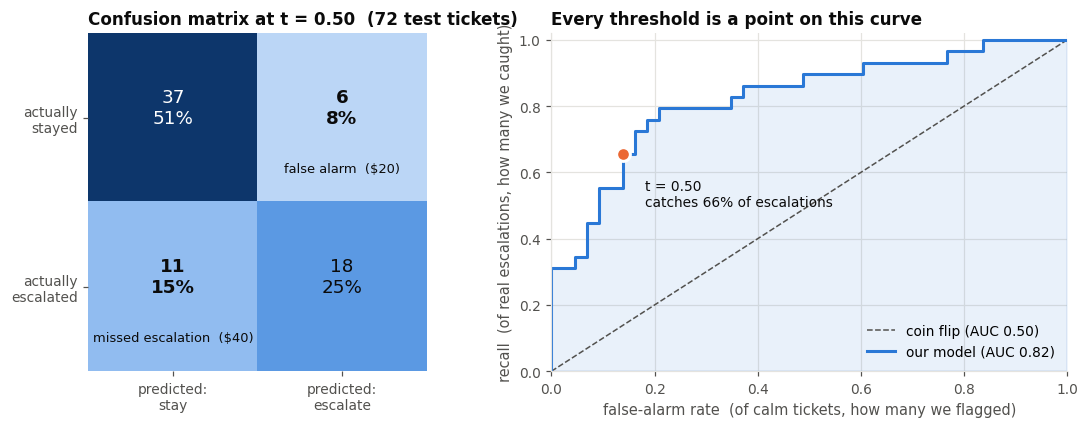

In [10]:
fpr, tpr, roc_t = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.0))

# ── Left: confusion matrix as a heatmap (sequential blue = magnitude) ────────
ERROR_NAME = {(0, 1): "false alarm  ($20)", (1, 0): "missed escalation  ($40)"}
ax1.imshow(cm, cmap=BLUES, vmin=0, vmax=cm.max())
for (i, j), v in np.ndenumerate(cm):
    fg = SURFACE if v > cm.max() * 0.55 else INK
    ax1.text(j, i - 0.06, f"{v}\n{v / cm.sum():.0%}", ha="center", va="center",
             fontsize=12, color=fg, fontweight="bold" if i != j else "normal")
    if (i, j) in ERROR_NAME:
        ax1.text(j, i + 0.30, ERROR_NAME[(i, j)], ha="center", va="center",
                 fontsize=8.5, color=fg)
ax1.set_xticks([0, 1]); ax1.set_xticklabels(["predicted:\nstay", "predicted:\nescalate"])
ax1.set_yticks([0, 1]); ax1.set_yticklabels(["actually\nstayed", "actually\nescalated"])
ax1.set_title(f"Confusion matrix at t = 0.50  ({cm.sum()} test tickets)")
ax1.grid(False)
for s in ax1.spines.values():
    s.set_visible(False)

# ── Right: ROC curve, with the t = 0.50 operating point marked ──────────────
ax2.plot([0, 1], [0, 1], color=INK_SOFT, linestyle="--", linewidth=1, label="coin flip (AUC 0.50)")
ax2.fill_between(fpr, tpr, color=BLUE, alpha=0.10)
ax2.plot(fpr, tpr, color=BLUE, linewidth=2, label=f"our model (AUC {auc:.2f})")

k = int(np.argmin(np.abs(roc_t - 0.5)))
ax2.plot([fpr[k]], [tpr[k]], marker="o", markersize=9, color=ORANGE,
         markeredgecolor=SURFACE, markeredgewidth=2, zorder=5)
ax2.annotate(f"t = 0.50\ncatches {tpr[k]:.0%} of escalations",
             xy=(fpr[k], tpr[k]), xytext=(14, -34), textcoords="offset points",
             fontsize=9, color=INK)

ax2.set_xlabel("false-alarm rate  (of calm tickets, how many we flagged)")
ax2.set_ylabel("recall  (of real escalations, how many we caught)")
ax2.set_title("Every threshold is a point on this curve")
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1.02)
ax2.grid(True, axis="both")
ax2.legend(loc="lower right")
plt.tight_layout()
plt.show()

> 🔬 **What the picture says.** The bold off-diagonal cells are the whole argument for §2.5: the model at the default `t = 0.50` is not obviously *wrong*, it is merely **un-priced**. Sliding along the ROC curve trades one error for the other, and nothing in either picture tells you where to stop — only the dollar values can. Note too that AUC is threshold-*free*: it grades the ranking, which is why we quote it to prove the model works and quote dollars to prove it pays.

### 2.5 From probability to a costed decision

> 🧠 **Model → money → decision.** The model outputs a probability; the *business* needs a yes/no. Where you put the threshold is an economic choice, not a statistical one. Two costs decide it:
> - **A missed escalation** (`COST_MISS`) — the ticket blows up and the customer churns: **\$40**.
> - **A false alarm** (`COST_FALSE`) — a senior agent proactively handles a ticket that would have been fine: **\$20**.
>
> Sweep the threshold, price each outcome, and pick the threshold that **minimises expected cost**. Then compare it to the two things a manager might do *without* a model: escalate nothing, or escalate everything.


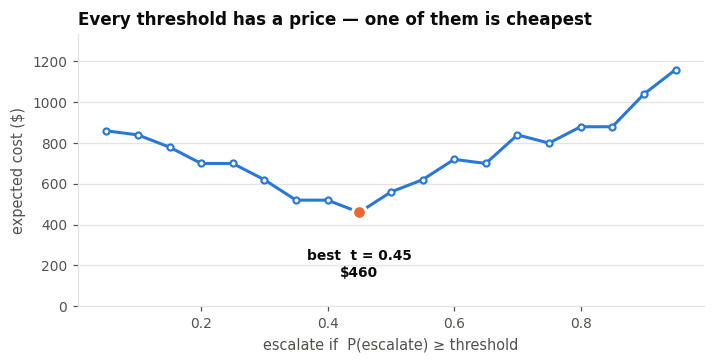

Best threshold      : 0.45  → flags 28 of 72 test tickets
Cost of the rule    : $460
Escalate nothing    : $1,160
Escalate everything : $860
Saving vs best naive: $400  on 72 tickets


In [11]:
COST_MISS  = 40.0   # a missed escalation (churn / blow-up)
COST_FALSE = 20.0   # a needless senior-agent touch

def total_cost(y_true, flagged):
    tn, fp, fn, tp = confusion_matrix(y_true, flagged, labels=[0, 1]).ravel()
    return fn * COST_MISS + fp * COST_FALSE

thresholds = np.linspace(0.05, 0.95, 19)
costs = [total_cost(y_test, (proba >= t).astype(int)) for t in thresholds]
best_i = int(np.argmin(costs))
best_t = float(thresholds[best_i])

cost_model = costs[best_i]
cost_none  = total_cost(y_test, np.zeros_like(y_test))   # escalate nothing
cost_all   = total_cost(y_test, np.ones_like(y_test))    # escalate everything
n_flagged  = int((proba >= best_t).sum())

fig, ax = plt.subplots(figsize=(6.6, 3.4))
ax.plot(thresholds, costs, color=BLUE, linewidth=2, marker="o", markersize=4,
        markerfacecolor=SURFACE, markeredgecolor=BLUE, markeredgewidth=1.4)
ax.plot([best_t], [cost_model], marker="o", markersize=9, color=ORANGE,
        markeredgecolor=SURFACE, markeredgewidth=2, zorder=5)
ax.annotate(f"best  t = {best_t:.2f}\n${cost_model:,.0f}",
            xy=(best_t, cost_model), xytext=(0, -42), textcoords="offset points",
            ha="center", fontsize=9, color=INK, fontweight="bold")

ax.set_xlabel("escalate if  P(escalate) ≥ threshold")
ax.set_ylabel("expected cost ($)")
ax.set_title("Every threshold has a price — one of them is cheapest")
ax.set_ylim(0, max(costs) * 1.15)
plt.tight_layout()
plt.show()

print(f"Best threshold      : {best_t:.2f}  → flags {n_flagged} of {len(y_test)} test tickets")
print(f"Cost of the rule    : ${cost_model:,.0f}")
print(f"Escalate nothing    : ${cost_none:,.0f}")
print(f"Escalate everything : ${cost_all:,.0f}")
print(f"Saving vs best naive: ${min(cost_none, cost_all) - cost_model:,.0f}  on {len(y_test)} tickets")

#### 💰 The slide the manager actually reads

The sweep proved a threshold exists. This chart proves it is **worth having**, by putting the rule beside the two things a manager can do for free — and splitting each bar into *what kind* of mistake we are paying for. "Escalate nothing" pays only for blow-ups; "escalate everything" pays only for wasted senior-agent time; the costed rule buys a little of each on purpose.

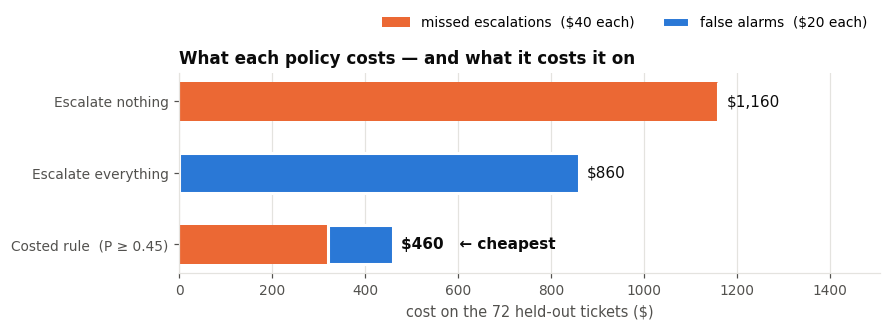

                         missed escalations ($)  false alarms ($)  total ($)
Escalate nothing                           1160                 0       1160
Escalate everything                           0               860        860
Costed rule  (P ≥ 0.45)                     320               140        460


In [12]:
STRATEGIES = {
    "Escalate nothing":                 np.zeros(len(y_test), dtype=int),
    "Escalate everything":              np.ones(len(y_test), dtype=int),
    f"Costed rule  (P ≥ {best_t:.2f})": (proba >= best_t).astype(int),
}

def cost_split(flagged):
    """Return the cost of the two error types separately."""
    tn, fp, fn, tp = confusion_matrix(y_test, flagged, labels=[0, 1]).ravel()
    return fn * COST_MISS, fp * COST_FALSE

names  = list(STRATEGIES)
missed = np.array([cost_split(f)[0] for f in STRATEGIES.values()])
false_ = np.array([cost_split(f)[1] for f in STRATEGIES.values()])
totals = missed + false_
ypos   = np.arange(len(names))[::-1]

fig, ax = plt.subplots(figsize=(8.2, 3.2))
ax.barh(ypos, missed, height=0.55, color=ORANGE,
        label=f"missed escalations  (${COST_MISS:,.0f} each)")
ax.barh(ypos, false_, left=missed, height=0.55, color=BLUE,
        edgecolor=SURFACE, linewidth=2,          # a 2px surface gap, not a border
        label=f"false alarms  (${COST_FALSE:,.0f} each)")

for y, t, name in zip(ypos, totals, names):
    tag = "   ← cheapest" if t == totals.min() else ""
    ax.text(t + totals.max() * 0.015, y, f"${t:,.0f}{tag}", va="center",
            fontsize=10, color=INK, fontweight="bold" if t == totals.min() else "normal")

ax.set_yticks(ypos); ax.set_yticklabels(names)
ax.set_xlabel(f"cost on the {len(y_test)} held-out tickets ($)")
ax.set_xlim(0, totals.max() * 1.30)
ax.set_title("What each policy costs — and what it costs it on")
ax.grid(False); ax.grid(True, axis="x")
ax.legend(loc="lower right", bbox_to_anchor=(1, 1.15), ncols=2)
plt.tight_layout()
plt.show()

print(pd.DataFrame({"missed escalations ($)": missed, "false alarms ($)": false_,
                    "total ($)": totals}, index=names).astype(int))

> 🔬 **What the picture says.** The naive policies are *pure* — one colour each — and that is precisely their failure: each one refuses to spend a dollar to save two. The rule's bar is mixed, shorter, and the only one whose length you chose deliberately. Change `COST_MISS` or `COST_FALSE` and this chart redraws — which is the honest admission that **the answer belongs to finance, not to the model.**

> 🎯 **That's the whole of Part A in one sentence:** a model that ranks tickets by escalation risk, turned into a threshold that escalates the risky ones and **saves real money** versus escalating everything or nothing. The number that leaves this room isn't the AUC — it's the dollar figure.


## 3. Part B — AI assistant: from text to structure

> 🧭 **Text → structure.** The metadata got us a decision. But the *content* of each ticket is still an unread paragraph. Part B reads it: classify → draft or route → evaluate. We reuse the exact offline `MockLLM` from NB 10 — swap one line for a real provider and nothing else changes.


In [13]:
# MockLLM lives in llm_providers.py so every AI notebook uses the same one.
# Swap it for any real provider by changing this one line — the rest of the
# notebook stays identical:
#
#     from llm_providers import OpenAILLM as LLM      # needs `pip install openai`
#     from llm_providers import AnthropicLLM as LLM   # needs `pip install anthropic`
#     from llm_providers import GoogleLLM as LLM      # needs `pip install google-generativeai`
#     from llm_providers import OllamaLLM as LLM      # local — needs Ollama running
import json, re, random, time
from textwrap import shorten

# Make the repo-root llm_providers.py importable no matter which folder
# Jupyter launched from (it lives one level up, at the course root).
import sys, pathlib
_root = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
              if (p / "llm_providers.py").exists()), None)
if _root:                       # local checkout — use the repo's module
    sys.path.insert(0, str(_root))
else:                           # Colab / standalone — fetch it next to the notebook
    import urllib.request
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/ChrisW09/Python-for-AI-Driven-Automation"
        "/main/llm_providers.py", "llm_providers.py")
from llm_providers import MockLLM

llm = MockLLM(seed=42)
print('MockLLM ready ✅')


MockLLM ready ✅


### 3.1 Classify every ticket into structured labels

**The first station stamps two machine-readable labels on each ticket** — `sentiment` and `topic` — as strict JSON. Structured output is the bridge: downstream code can't branch on a paragraph, but it can branch on `{"sentiment": "negative", "topic": "billing"}`. We wrap `json.loads` in `try / except` because real models occasionally hand back almost-JSON.


In [14]:
CLASSIFY_SYSTEM = (
    "You analyse a customer support ticket. "
    "Return JSON with keys 'sentiment' (positive/neutral/negative) and "
    "'topic' (billing/tech/feature/other). Reply with the JSON only."
)

def classify(text):
    r = llm.chat(messages=[
        {"role": "system", "content": CLASSIFY_SYSTEM},
        {"role": "user",   "content": text},
    ], temperature=0.0)
    try:
        labels = json.loads(r["text"])
    except json.JSONDecodeError:
        labels = {"sentiment": "unknown", "topic": "unknown"}
    return {
        "sentiment":  labels.get("sentiment", "unknown"),
        "topic":      labels.get("topic", "unknown"),
        "tokens_in":  r["tokens_in"],
        "tokens_out": r["tokens_out"],
        "latency_s":  r["latency_s"],
    }

# Run the classifier over every ticket and attach the results as columns.
records   = [classify(t) for t in tickets["text"]]
labels_df = pd.DataFrame(records, index=tickets.index)
tickets["sentiment"] = labels_df["sentiment"]
tickets["topic"]     = labels_df["topic"]

print("sentiment:", tickets["sentiment"].value_counts().to_dict())
print("topic    :", tickets["topic"].value_counts().to_dict())
tickets[["text", "sentiment", "topic"]].head(4)


sentiment: {'neutral': 97, 'negative': 86, 'positive': 57}
topic    : {'billing': 80, 'feature': 69, 'tech': 66, 'other': 25}


,text,sentiment,topic
0,Please cancel my subscription. The price is to...,negative,billing
1,Please cancel my subscription. The price is to...,negative,billing
2,Love the product. Could you add a dark mode fe...,positive,feature
3,Question about my subscription and monthly bil...,neutral,billing


#### 🗂️ What the assistant read out of 240 paragraphs

Two label columns now exist where before there was only prose. A **heatmap of topic × sentiment** is the fastest way to check them: it shows the volume mix *and* where the anger is concentrated, in one glance. One hue, light → dark, because these are magnitudes, not identities.

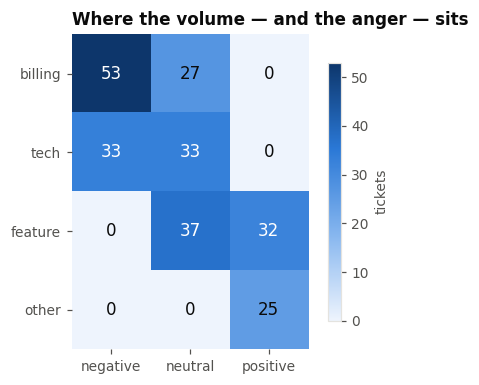

sentiment  negative  neutral  positive
topic                                 
billing          53       27         0
tech             33       33         0
feature           0       37        32
other             0        0        25


In [15]:
mix = pd.crosstab(tickets["topic"], tickets["sentiment"])
mix = mix.reindex(index=[t for t in ["billing", "tech", "feature", "other"] if t in mix.index],
                  columns=[s for s in ["negative", "neutral", "positive"] if s in mix.columns])

fig, ax = plt.subplots(figsize=(6.2, 3.6))
im = ax.imshow(mix.values, cmap=BLUES, vmin=0, vmax=mix.values.max())
for (i, j), v in np.ndenumerate(mix.values):
    ax.text(j, i, f"{v}", ha="center", va="center", fontsize=11,
            color=SURFACE if v > mix.values.max() * 0.55 else INK)

ax.set_xticks(range(mix.shape[1])); ax.set_xticklabels(mix.columns)
ax.set_yticks(range(mix.shape[0])); ax.set_yticklabels(mix.index)
ax.set_title("Where the volume — and the anger — sits")
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
fig.colorbar(im, ax=ax, shrink=0.82, pad=0.03).set_label("tickets", color=INK_SOFT, fontsize=9)
plt.tight_layout()
plt.show()

print(mix)

> 🔬 **What the picture says.** The dark corner is *negative × billing* — the cell that the routing rules in §3.2 are about to send straight to a human, and the same population §2 flagged as expensive. Two independent halves of the project pointing at one queue is the strongest signal this notebook produces. Read the empty cells too: an all-zero row would mean a topic the classifier never uses, which is usually a prompt bug rather than a fact about your customers.

---

### ✋ Quick exercise (~2 min) — A one-label sentiment classifier

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Sometimes you only need the sentiment, not the whole JSON. Write `classify_sentiment(text)` that returns **exactly one** of `positive` / `neutral` / `negative` — nothing else — by calling `llm.chat` with a system prompt that asks it to *classify sentiment* and reply with only the label.

```python
def classify_sentiment(text):
    ...  # call llm.chat, return the single label
```


In [16]:
# ✍️ Your turn 👇
# Return exactly one of "positive" / "neutral" / "negative".
def classify_sentiment(text):
    ...

# print(classify_sentiment("The login page is broken and throws an error. Awful."))


<details>
<summary>✅ <b>Solution</b></summary>

```python
def classify_sentiment(text):
    r = llm.chat(messages=[
        {"role": "system", "content":
            "Classify the sentiment as positive, neutral, or negative. Reply with only the label."},
        {"role": "user", "content": text},
    ], temperature=0.0)
    return r["text"].strip().lower()

print(classify_sentiment("The login page is broken and throws an error. Awful."))  # negative
```

Same `llm.chat` shape as `classify`, but the system prompt asks for a bare label instead of JSON — so there is nothing to parse. `temperature=0.0` keeps it deterministic. This is the cheapest possible AI feature: one call in, one word out.
</details>


### 3.2 Draft a reply — rules + retrieval

Now *act* on the labels. Two moves:

1. **A rules engine** decides routing: a **negative** ticket about **billing** or **tech** is escalated to a human; everything else the assistant can safely auto-answer.
2. **Retrieval** grounds the auto-answer: a tiny knowledge base of canned snippets, scored by keyword overlap (the keyword-RAG from NB 10), supplies the reply text — so nothing is made up.


In [17]:
# A tiny in-house knowledge base: one canned snippet per topic.
KB = {
    "billing": ("Our billing team can review any charge and issue refunds within 5 business days. "
                "Manage invoices and payment methods under Settings -> Billing."),
    "tech":    ("For a login or loading error, clear your cache and reset your password at /reset. "
                "Most access issues clear within a few minutes."),
    "feature": ("Thanks for the idea! We track every feature request on our public roadmap and "
                "prioritise by votes."),
    "other":   "Thanks for reaching out — a support specialist will follow up with next steps.",
}

def keyword_score(query, doc):
    q = set(re.findall(r"[a-zA-Z']+", query.lower()))
    d = set(re.findall(r"[a-zA-Z']+", doc.lower()))
    return len(q & d)

def retrieve_snippet(text, topic):
    # Rank KB snippets by keyword overlap with the ticket; the classified topic
    # breaks ties so the reply stays on-subject.
    scores = {k: keyword_score(text, v) + (2 if k == topic else 0) for k, v in KB.items()}
    best = max(scores, key=scores.get)
    return KB[best]

ESCALATE_TOPICS = {"billing", "tech"}

def handle(row):
    if row["sentiment"] == "negative" and row["topic"] in ESCALATE_TOPICS:
        return pd.Series({"ai_action": "escalate", "draft": ""})
    snippet = retrieve_snippet(row["text"], row["topic"])
    return pd.Series({"ai_action": "auto_reply", "draft": f"Hi — thanks for reaching out. {snippet}"})

tickets[["ai_action", "draft"]] = tickets.apply(handle, axis=1)
print("actions:", tickets["ai_action"].value_counts().to_dict())
print("\nExample auto-reply:")
print(" ", tickets.loc[tickets["ai_action"] == "auto_reply", "draft"].iloc[0])


actions: {'auto_reply': 154, 'escalate': 86}

Example auto-reply:
  Hi — thanks for reaching out. Thanks for the idea! We track every feature request on our public roadmap and prioritise by votes.


---

### ✋ Quick exercise (~2 min) — What share did we auto-resolve?

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

The assistant either drafted a reply (`ai_action == "auto_reply"`) or escalated. Compute the **auto-resolve rate** — the fraction of tickets it handled without a human — from the `tickets` table.

```python
auto_resolve_rate = ...  # fraction where ai_action == "auto_reply"
```


In [18]:
# ✍️ Your turn 👇
# Fraction of tickets whose ai_action == "auto_reply".
auto_resolve_rate = ...
# print(f"{auto_resolve_rate:.0%}")


<details>
<summary>✅ <b>Solution</b></summary>

```python
auto_resolve_rate = (tickets["ai_action"] == "auto_reply").mean()
n_auto = int((tickets["ai_action"] == "auto_reply").sum())
print(f"Auto-resolve rate: {auto_resolve_rate:.0%}  ({n_auto} of {len(tickets)} tickets)")
```

A boolean Series (`== "auto_reply"`) averages to the fraction of `True`s — the same trick as the escalation rate in Part A. This single number is the headline of an AI-support project: the share of overnight volume a human never has to touch.
</details>


#### 🚦 Where every ticket ended up

The rules engine has now split the night's work in two. Stack the outcome **per topic** and you can see at a glance which queues the assistant is genuinely absorbing and which it is merely forwarding — the number a manager will ask for first, because it is the one that turns into headcount.

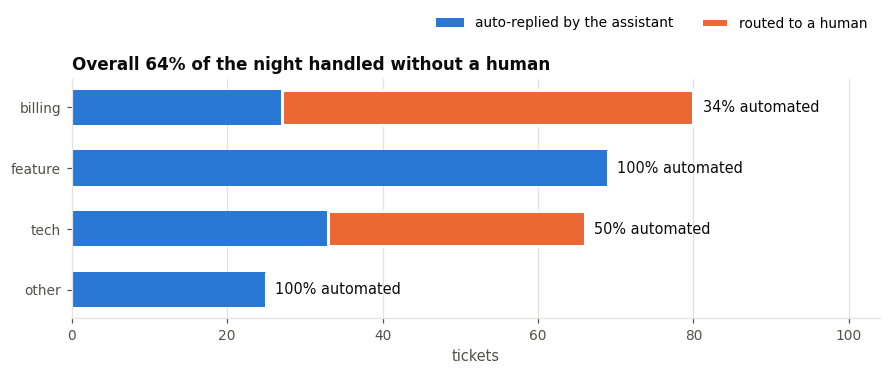

ai_action  auto_reply  escalate
topic                          
other              25         0
tech               33        33
feature            69         0
billing            27        53


In [19]:
route = pd.crosstab(tickets["topic"], tickets["ai_action"])
for col in ["auto_reply", "escalate"]:
    if col not in route.columns:
        route[col] = 0
route = route[["auto_reply", "escalate"]]
route = route.loc[route.sum(axis=1).sort_values().index]

ypos = np.arange(len(route))
fig, ax = plt.subplots(figsize=(8.2, 3.6))
ax.barh(ypos, route["auto_reply"], height=0.58, color=BLUE, label="auto-replied by the assistant")
ax.barh(ypos, route["escalate"], left=route["auto_reply"], height=0.58, color=ORANGE,
        edgecolor=SURFACE, linewidth=2, label="routed to a human")

totals = route.sum(axis=1).values
for y, a, t in zip(ypos, route["auto_reply"].values, totals):
    ax.text(t + totals.max() * 0.015, y, f"{a / t:.0%} automated", va="center",
            fontsize=9.5, color=INK)

auto_rate = (tickets["ai_action"] == "auto_reply").mean()
ax.set_yticks(ypos); ax.set_yticklabels(route.index)
ax.set_xlabel("tickets")
ax.set_xlim(0, totals.max() * 1.30)
ax.set_title(f"Overall {auto_rate:.0%} of the night handled without a human")
ax.grid(False); ax.grid(True, axis="x")
ax.legend(loc="lower right", bbox_to_anchor=(1, 1.15), ncols=2)
plt.tight_layout()
plt.show()

print(route)

> 🔬 **What the picture says.** `feature` and `other` are almost fully automated — they are requests, not problems. `billing` and `tech` are the split queues, because only their *negative* half trips the escalation rule. That is the design working as intended: **automation is not uniform, and it should not be.** If you want a higher headline number, the honest lever is a better classifier or a narrower `ESCALATE_TOPICS`, not a looser rule — and §3.3 is where you check whether the classifier has earned that trust.

### 3.3 A tiny evaluation — golden set + cost trace

> 🔬 **Code → test → ship → observe.** Before trusting the classifier, check it against a **golden set**: a handful of tickets *you* labelled by hand. Accuracy on the golden set is your regression test — re-run it in seconds after any prompt change. And every run should leave a **trace**: tokens, latency, cost. No trace, no observability.


In [20]:
# A hand-labelled golden set. Two cases are deliberately hard — the mock's
# keyword rules disagree with a human reader — so accuracy is honestly < 100%.
GOLDEN = [
    ("I want a refund. The invoice charge is wrong and this is frustrating.", "negative", "billing"),
    ("The login page is broken and throws an error. Awful.",                  "negative", "tech"),
    ("Please add a CSV export feature to the dashboard.",                     "neutral",  "feature"),
    ("Amazing support, thank you so much. You are fantastic and excellent.",  "positive", "other"),
    ("Please cancel my subscription. The price is too high, worst value.",    "negative", "billing"),
    ("Works fine now, no issues at all.",                                     "positive", "other"),   # mock -> neutral
    ("The password reset is stuck on a loading screen.",                      "negative", "tech"),    # mock -> neutral
]

correct = 0
for text, gold_sent, gold_topic in GOLDEN:
    out = classify(text)
    ok = out["sentiment"] == gold_sent and out["topic"] == gold_topic
    correct += int(ok)
    print(f"  {'✅' if ok else '❌'} pred=({out['sentiment']},{out['topic']})  "
          f"gold=({gold_sent},{gold_topic})  ←  {text[:40]}")

golden_acc = correct / len(GOLDEN)
# Cost of the FULL classify pass over all tickets (same per-1K prices as NB 10).
cost_usd = (labels_df["tokens_in"].sum() / 1000 * 0.0006 +
            labels_df["tokens_out"].sum() / 1000 * 0.0024)
print(f"\nGolden-set accuracy : {golden_acc:.0%}  ({correct}/{len(GOLDEN)})")
print(f"Trace (full pass)   : {labels_df['tokens_in'].sum():,} tok in · "
      f"{labels_df['tokens_out'].sum():,} tok out · "
      f"{labels_df['latency_s'].sum()*1000:.0f} ms · ${cost_usd:.4f}")


  ✅ pred=(negative,billing)  gold=(negative,billing)  ←  I want a refund. The invoice charge is w
  ✅ pred=(negative,tech)  gold=(negative,tech)  ←  The login page is broken and throws an e
  ✅ pred=(neutral,feature)  gold=(neutral,feature)  ←  Please add a CSV export feature to the d
  ✅ pred=(positive,other)  gold=(positive,other)  ←  Amazing support, thank you so much. You 
  ✅ pred=(negative,billing)  gold=(negative,billing)  ←  Please cancel my subscription. The price
  ❌ pred=(neutral,other)  gold=(positive,other)  ←  Works fine now, no issues at all.
  ❌ pred=(neutral,tech)  gold=(negative,tech)  ←  The password reset is stuck on a loading

Golden-set accuracy : 71%  (5/7)
Trace (full pass)   : 12,810 tok in · 4,080 tok out · 3 ms · $0.0175


## 4. The executive summary

**The one artefact that leaves the building.** The dashboards and traces are for you; the manager wants a short brief they can act on before their coffee's cold. Combine the money number from Part A with the throughput and quality numbers from Part B.


In [21]:
n          = len(tickets)
n_escalate = int((tickets["ai_action"] == "escalate").sum())
n_auto     = int((tickets["ai_action"] == "auto_reply").sum())
neg_bill   = int(((tickets["sentiment"] == "negative") & (tickets["topic"] == "billing")).sum())
top_topic  = tickets["topic"].value_counts().idxmax()
saving     = min(cost_none, cost_all) - cost_model

line = "=" * 64
print(line)
print("  OVERNIGHT SUPPORT-OPS BRIEF")
print(line)
print(f"  📥  {n} tickets processed. Auto-resolved {n_auto} ({n_auto/n:.0%}); "
      f"{n_escalate} routed to a human.")
print(f"  🤖  Escalation model ranks risk at ROC-AUC {roc_auc_score(y_test, proba):.2f}.")
print(f"  💰  Costed rule: escalate the riskiest at P≥{best_t:.2f} → "
      f"${saving:,.0f} saved per {len(y_test)} tickets vs. escalating everything.")
print(f"  🚨  {neg_bill} negative billing tickets — watch for a refund-process spike.")
print(f"  🧪  Classifier golden-set accuracy {golden_acc:.0%}; "
      f"overnight LLM spend ${cost_usd:.4f}.")
print(f"  📊  Most common topic: '{top_topic}'.")
print(line)


  OVERNIGHT SUPPORT-OPS BRIEF
  📥  240 tickets processed. Auto-resolved 154 (64%); 86 routed to a human.
  🤖  Escalation model ranks risk at ROC-AUC 0.82.
  💰  Costed rule: escalate the riskiest at P≥0.45 → $400 saved per 72 tickets vs. escalating everything.
  🚨  53 negative billing tickets — watch for a refund-process spike.
  🧪  Classifier golden-set accuracy 71%; overnight LLM spend $0.0175.
  📊  Most common topic: 'billing'.


### 📇 The same brief, as one picture

The text block above is what you paste into Slack. This is what you put on a slide: four numbers, no chart junk, each one the answer to a question a manager actually asked. **Sometimes the right visualisation is not a chart at all** — when the story is a handful of headline figures, stat tiles beat any bar chart you could draw of them.

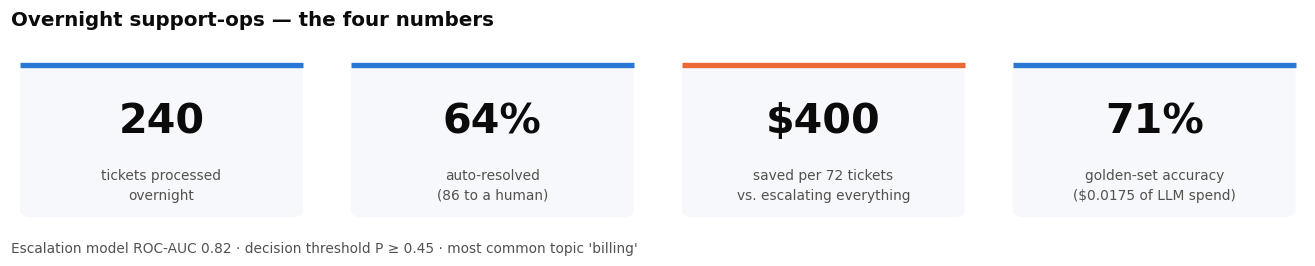

In [22]:
tiles = [
    (f"{n:,}",             "tickets processed\novernight",              BLUE),
    (f"{n_auto / n:.0%}",  f"auto-resolved\n({n_escalate} to a human)", BLUE),
    (f"${saving:,.0f}",    f"saved per {len(y_test)} tickets\nvs. escalating everything", ORANGE),
    (f"{golden_acc:.0%}",  f"golden-set accuracy\n(${cost_usd:.4f} of LLM spend)", BLUE),
]

fig, axes = plt.subplots(1, len(tiles), figsize=(12, 2.3))
for ax, (value, label, accent) in zip(axes, tiles):
    ax.set_axis_off()
    ax.add_patch(FancyBboxPatch((0.03, 0.06), 0.94, 0.86, transform=ax.transAxes,
                                boxstyle="round,pad=0,rounding_size=0.04",
                                facecolor=CARD, edgecolor="none", clip_on=False))
    ax.plot([0.03, 0.97], [0.92, 0.92], transform=ax.transAxes, color=accent,
            lw=3.5, solid_capstyle="butt", clip_on=False)
    ax.text(0.5, 0.60, value, transform=ax.transAxes, ha="center", va="center",
            fontsize=27, fontweight="bold", color=INK)
    ax.text(0.5, 0.24, label, transform=ax.transAxes, ha="center", va="center",
            fontsize=9, color=INK_SOFT, linespacing=1.5)

fig.subplots_adjust(left=0.01, right=0.99, top=0.80, bottom=0.10, wspace=0.10)
fig.suptitle("Overnight support-ops — the four numbers", x=0.01, y=0.96, ha="left",
             fontsize=13, fontweight="bold", color=INK)
fig.text(0.01, 0.005, f"Escalation model ROC-AUC {roc_auc_score(y_test, proba):.2f} · "
                      f"decision threshold P ≥ {best_t:.2f} · most common topic '{top_topic}'",
         ha="left", fontsize=9, color=INK_SOFT)
plt.show()

> 🔬 **What the picture says.** Notice what is *absent*: no AUC in 40-point type, no confusion matrix, no token count. Those live in the footnote or in your notebook, because they answer questions the manager did not ask. The four numbers on the tiles each close a loop opened in §1 — volume, automation, **money**, and trust — and money is the only one in a different colour, because it is the only one anybody will repeat.

## 🧪 Practice exercises

### Exercise 1 — ⭐ Topic mix

Print how many tickets fall under each `topic`, most common first. One line with `value_counts()`.


In [23]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
print(tickets["topic"].value_counts())
```

`value_counts()` sorts by frequency by default — an instant topic distribution you can drop straight into a report.
</details>


### Exercise 2 — ⭐⭐ A stricter rule

Management wants fewer false alarms. Recompute the decision cost at a **stricter** threshold of `0.70` and compare it to the cost-optimal `best_t`. Which is cheaper, and by how much? Reuse `total_cost`, `proba`, and `y_test`.


In [24]:
# Your code here  👇
strict_t = 0.70


<details>
<summary>💡 <b>Solution</b></summary>

```python
strict_t = 0.70
cost_strict = total_cost(y_test, (proba >= strict_t).astype(int))
print(f"best_t={best_t:.2f}: ${cost_model:,.0f}    strict={strict_t:.2f}: ${cost_strict:,.0f}")
print(f"The cost-optimal threshold is ${cost_strict - cost_model:,.0f} cheaper.")
```

A stricter threshold flags fewer tickets, so false alarms drop — but misses rise, and each miss costs twice a false alarm here. The sweep already found the minimum; moving off it costs money in one direction or the other.
</details>


### Exercise 3 — ⭐⭐ VIP safety net

Enterprise customers are worth protecting. Add a rule: **any `enterprise` ticket with negative sentiment is escalated**, even when its topic isn't billing or tech. How many *extra* tickets does that escalate? Work on a copy so you don't overwrite `tickets`.


In [25]:
# Your code here  👇
vip = tickets.copy()


<details>
<summary>💡 <b>Solution</b></summary>

```python
vip = tickets.copy()
extra = ((vip["plan"] == "enterprise") & (vip["sentiment"] == "negative")
         & (vip["ai_action"] == "auto_reply"))
vip.loc[extra, "ai_action"] = "escalate"
print(f"VIP rule escalated {int(extra.sum())} extra ticket(s).")
print(vip["ai_action"].value_counts().to_dict())
```

Business rules like this sit *on top of* the model, not inside it — they encode a value judgement ("never let a VIP churn silently") the data alone can't express. Keeping them as an explicit, auditable layer is good practice.
</details>


### Exercise 4 — ⭐⭐ Debug me 🐞

The cell below wants structured labels, but it crashes with a `JSONDecodeError`. Read the system prompt, work out why the mock didn't return JSON, then write the fixed call in the next cell.


In [26]:
# 🐞 BUG (INTENTIONALLY ERRORS): the system prompt never asks for JSON,
# so the mock returns prose — and json.loads() chokes on it.
resp = llm.chat(messages=[
    {"role": "system", "content": "You are a helpful support analyst."},
    {"role": "user",   "content": tickets.loc[0, "text"]},
])
labels = json.loads(resp["text"])   # 💥 JSONDecodeError
print(labels)


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [27]:
# 👇 Your fixed version goes here.


<details>
<summary>💡 <b>Solution</b></summary>

```python
resp = llm.chat(messages=[
    {"role": "system", "content":
        "Return JSON with keys 'sentiment' and 'topic'. Reply with the JSON only."},
    {"role": "user",   "content": tickets.loc[0, "text"]},
])
labels = json.loads(resp["text"])
print(labels)
```

The mock (like a real model) only emits JSON when the **system prompt asks for it** — the words "Return JSON with keys …" are what trigger structured output. A vague prompt gets prose, and `json.loads` raises. Fix the *prompt*, not the parser — and keep the `try / except` from Section 3.1 as a seatbelt for the times a real model still slips.
</details>


## 🧠 Stretch exercises

Two harder, interview-flavoured extensions. Try each before opening the solution.


### Stretch exercise C — ⭐⭐⭐ What is model quality worth, in dollars?

Part A priced the decision *rule*. Now price the **model's skill**. Blend its probabilities toward a coin flip by a factor `alpha`: `p = (1 - alpha) * proba + alpha * 0.5`. For each `alpha` in `[0, 0.25, 0.5, 0.75, 1.0]`, find the cheapest decision cost (sweep the threshold) and report the saving versus escalate-everything. Watch the saving collapse as the model degrades toward random.


In [28]:
# Your code here  👇
# Blend proba toward 0.5 and watch the dollar saving vs escalate-all shrink.
alphas = [0.0, 0.25, 0.5, 0.75, 1.0]


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
alphas = [0.0, 0.25, 0.5, 0.75, 1.0]
for a in alphas:
    p = (1 - a) * proba + a * 0.5
    model_c = min(total_cost(y_test, (p >= t).astype(int))
                  for t in np.linspace(0.05, 0.95, 19))
    print(f"alpha={a:.2f}  (noise {a:.0%})  model=${model_c:,.0f}  "
          f"saving vs all=${cost_all - model_c:,.0f}")
```

**Reasoning.** A model is worth *exactly* the dollars it saves. At `alpha=0` you have the real model and the full saving; at `alpha=1` the probabilities are pure noise, the cheapest decision degenerates to escalate-everything, and the saving falls to **\$0**. That collapse is the whole business case in one column: the gap between the trained model and a coin flip is what your ML work is worth — and it's why AUC alone never justifies a project, but AUC *priced against a baseline* does.
</details>


### Stretch exercise D — ⭐⭐⭐ Confidence-gated auto-replies

Auto-replying with a weak retrieval match is worse than escalating. Add a **confidence gate**: keep an `auto_reply` only if the best KB snippet shares at least **2** keywords with the ticket; otherwise downgrade it to `escalate`. Report how many auto-replies you would hold back. Work on a copy of `tickets`.


In [29]:
# Your code here  👇
gated = tickets.copy()


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def best_score(text):
    return max(keyword_score(text, snip) for snip in KB.values())

gated = tickets.copy()
weak = (gated["ai_action"] == "auto_reply") & (gated["text"].map(best_score) < 2)
gated.loc[weak, "ai_action"] = "escalate"
print(f"Held back {int(weak.sum())} low-confidence auto-replies.")
print("Before:", tickets["ai_action"].value_counts().to_dict())
print("After :", gated["ai_action"].value_counts().to_dict())
```

**Reasoning.** This is *graceful degradation*: the system does the easy, high-confidence work automatically and routes the ambiguous cases to a human, instead of confidently drafting a wrong reply. The gate is a single tunable knob (the keyword threshold) a product owner can dial between "cheap and risky" and "safe and slow" — exactly the kind of control an AI feature needs before it can be trusted in front of customers.
</details>


## 🧠 Key takeaways

One night of tickets, two halves of one job, one brief for the manager:

1. **One dataset, two questions.** Metadata → a *decision* (who escalates); text → *structure* (what's it about). Most real AI-ops projects are exactly this pair.
2. **A model is only useful once it's a decision.** The AUC is a diagnostic; the deliverable is a **threshold priced in dollars** — the cost of a miss versus a false alarm.
3. **Evaluate against a baseline, always.** Accuracy without the majority-class baseline, precision, and recall is theatre.
4. **Structured output is the bridge from text to automation.** Once the LLM returns JSON, the rest is ordinary Python — rules and retrieval.
5. **Rules + retrieval beat a bare LLM for support.** Route the risky cases to a human; ground the safe replies in your own knowledge base so nothing is made up.
6. **Ship with a golden set and a trace.** A 7-line eval you can re-run in seconds, plus tokens / latency / cost per run, is what turns a demo into a system you can trust.
7. **The executive summary is the product.** Everything upstream exists to produce a few lines a manager can act on before their coffee's cold.

8. **A chart is an argument, not decoration.** Every figure above answers exactly one question, in the form that question deserves — small multiples to compare candidate drivers, a heatmap for magnitude, a stacked bar to show *what* a policy pays for, stat tiles when the story is four numbers. And where a bucket held only ~60 tickets, the error bars said so; that is the only reason we didn't chase a trend that wasn't there.

> 🧭 **The mental model, one more time:** *numbers → decision, text → structure, then report.* If you can do those three things on one messy dataset, you can do the job.


## ✅ Self-assessment

- [ ] Generate and explore a small labelled dataset, reading rates straight off a `groupby`
- [ ] Engineer numeric features from text + categories and train a logistic classifier
- [ ] Evaluate against a majority baseline with precision, recall, and a confusion matrix
- [ ] Turn model probabilities into a cost-minimising decision threshold
- [ ] Classify free text into structured JSON labels with the `MockLLM`
- [ ] Combine rules + keyword retrieval to draft replies and route the hard cases
- [ ] Score a classifier on a golden set and report cost / latency for a run
- [ ] Write an executive summary that leads with the decision and the dollars
- [ ] Pick a chart form that fits the question, put error bars on a bucketed rate, and know when to stop charting and just print the number


## 🚀 Next step

🎉 **Capstone complete.** You went from Python syntax to a complete, offline, end-to-end AI-ops project: a costed decision *and* a text-to-structure assistant, evaluated and summarised for a manager. That's the shape of real work.

One breadth notebook remains — then you're done:

- 🕸️ **Continue with Notebook 22 (fast track) — Web Scraping & Open APIs** ([`22_web_scraping.ipynb`](22_web_scraping.ipynb)) — pull data off the web responsibly (BeautifulSoup, `robots.txt`, and the *check-for-an-API-first* rule).

Where to go after that — the **full course** has the depth the fast track trimmed:

- 🎓 **Start here:** [`../00_onboarding/00_master_onboarding.ipynb`](../00_onboarding/00_master_onboarding.ipynb) — the map of the whole course.
- 📊 The complete analytics capstone [`../15_capstones/47_capstone_analytics.ipynb`](../15_capstones/47_capstone_analytics.ipynb) — dashboards, statistics, clustering, and the interview-grade **Stretch A/B**.
- 🤖 The complete AI-assistant capstone [`../15_capstones/48_capstone_ai_assistant.ipynb`](../15_capstones/48_capstone_ai_assistant.ipynb) — validation, a priority engine, tracing, and a scheduled daily task.
- 📚 Then the module appendices — providers, evaluation frameworks, production, and deployment.

You have the fluency now to open any of those and *follow what's going on*. That was the whole point. Well done. 🏁
